## Business Understanding

### What is the business about?
The business is a B2B service called **ProcurePro Office**, which helps medium-sized organizations distribute office supplies efficiently through a supplier network.


### What problem is the business trying to solve?
The business is trying to reduce **supplier delivery uncertainty**. Specifically, it aims to identify high-risk purchase orders before the promised delivery date so that delays can be prevented or managed early.



### What decision can machine learning help the business make?
Machine learning can help the business predict which purchase orders are at high risk of delay, allowing the company to prioritize monitoring, take corrective actions, or adjust logistics planning in advance.


### What is the target variable in the dataset?
The target variable is:

**Supplier_Delay_Risk**

This represents whether a purchase order is at risk of delay.


### What are the input features?
The input features include all variables used to predict delay risk, such as:

- Supplier_Region  
- Contract_Type  
- Shipping_Mode  
- Payment_Terms  
- Seasonal_Period  
- Order_Value_CAD  
- Number_of_Line_Items  
- Promised_Lead_Time_Days  
- Past_On_Time_Rate  
- Supplier_Rating  
- Urgent_Order  
- Backorder_History  
- Quality_Incidents_Last_6M  
- Prior_Delays_Last_6M  
- Distance_KM  
- Inventory_Buffer_Days  
- Seasonal_Demand_Index  


### Why is this prediction useful for the business?
This prediction is useful because it allows the business to proactively identify risky suppliers and orders before delays happen. This improves supply chain efficiency by:

- Reducing late deliveries  
- Improving customer satisfaction  
- Helping managers prioritize high-risk orders  
- Allowing early intervention with suppliers  
- Optimizing logistics and inventory planning  

In [1]:
import pandas as pd 

In [3]:
df = pd.read_excel("procurepro_supplier_delay_risk_dataset.xlsx")

In [5]:
df.head()

,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Urgent_Order,Backorder_History,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,0.62,3.8,No,Rare,1,1,2455,2,1.15,Yes
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,0.64,4.2,No,NaN,0,3,1715,24,1.43,Yes
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,0.77,4.2,No,Rare,0,1,284,5,1.63,Yes
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,0.67,2.4,No,NaN,0,2,971,32,1.83,Yes
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,0.99,4.9,No,NaN,0,2,630,12,1.47,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Purchase_Order_ID          360 non-null    object 
 1   Supplier_Category          360 non-null    object 
 2   Supplier_Region            360 non-null    object 
 3   Contract_Type              360 non-null    object 
 4   Shipping_Mode              360 non-null    object 
 5   Payment_Terms              360 non-null    object 
 6   Seasonal_Period            360 non-null    object 
 7   Order_Value_CAD            360 non-null    float64
 8   Number_of_Line_Items       360 non-null    int64  
 9   Promised_Lead_Time_Days    360 non-null    int64  
 10  Past_On_Time_Rate          360 non-null    float64
 11  Supplier_Rating            360 non-null    float64
 12  Urgent_Order               360 non-null    object 
 13  Backorder_History          233 non-null    object 

In [11]:
df.shape

(360, 20)

In [15]:
df.isnull().sum()

Purchase_Order_ID              0
Supplier_Category              0
Supplier_Region                0
Contract_Type                  0
Shipping_Mode                  0
Payment_Terms                  0
Seasonal_Period                0
Order_Value_CAD                0
Number_of_Line_Items           0
Promised_Lead_Time_Days        0
Past_On_Time_Rate              0
Supplier_Rating                0
Urgent_Order                   0
Backorder_History            127
Quality_Incidents_Last_6M      0
Prior_Delays_Last_6M           0
Distance_KM                    0
Inventory_Buffer_Days          0
Seasonal_Demand_Index          0
Supplier_Delay_Risk            0
dtype: int64

In [19]:
df.duplicated().sum()

0

In [21]:
print(df['Backorder_History'].value_counts(dropna=False))

Backorder_History
Rare          129
NaN           127
Occasional     69
Frequent       35
Name: count, dtype: int64


In [23]:
df['Backorder_History'] = df['Backorder_History'].fillna('Rare')

In [25]:
# Features
X = df.drop('Supplier_Delay_Risk', axis=1)

# Target
y = df['Supplier_Delay_Risk']

In [27]:
print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

(360, 19)
(360,)
  Purchase_Order_ID    Supplier_Category   Supplier_Region     Contract_Type  \
0       PO-20260001   Breakroom Supplies  British Columbia      New Supplier   
1       PO-20260002       IT Accessories           Alberta   Approved Vendor   
2       PO-20260003  Packaging Materials           Ontario  Preferred Vendor   
3       PO-20260004    Printing Supplies        US Midwest      New Supplier   
4       PO-20260005   Breakroom Supplies            Quebec  Preferred Vendor   

      Shipping_Mode Payment_Terms  Seasonal_Period  Order_Value_CAD  \
0     Local Courier       Prepaid          Regular          4214.00   
1  Expedited Ground        Net 30  Fiscal Year End          6895.44   
2       Air Freight        Net 30     Holiday Rush          3890.34   
3   Standard Ground       Prepaid     Holiday Rush         10486.43   
4   Standard Ground        Net 30          Regular          4255.70   

   Number_of_Line_Items  Promised_Lead_Time_Days  Past_On_Time_Rate  \
0   

In [29]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Purchase_Order_ID', 'Supplier_Category', 'Supplier_Region',
       'Contract_Type', 'Shipping_Mode', 'Payment_Terms', 'Seasonal_Period',
       'Urgent_Order', 'Backorder_History'],
      dtype='object')


In [31]:
numerical_cols = X.select_dtypes(exclude=['object']).columns
print(numerical_cols)

Index(['Order_Value_CAD', 'Number_of_Line_Items', 'Promised_Lead_Time_Days',
       'Past_On_Time_Rate', 'Supplier_Rating', 'Quality_Incidents_Last_6M',
       'Prior_Delays_Last_6M', 'Distance_KM', 'Inventory_Buffer_Days',
       'Seasonal_Demand_Index'],
      dtype='object')


In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

# Create a one-hot encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(288, 331)
(72, 331)


In [51]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree classification model
decision_tree_model = DecisionTreeClassifier(
# Limit the depth of the tree to make it easier to understand
max_depth=4,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [67]:
decision_tree_model.fit(X_train_processed, y_train)

print("Model trained successfully.")

Model trained successfully.


In [69]:
y_pred = decision_tree_model.predict(X_test_processed)

In [71]:
print("Decision Tree Model Information")
# Print a separator line
print("-" * 50)
# Display the trained model
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


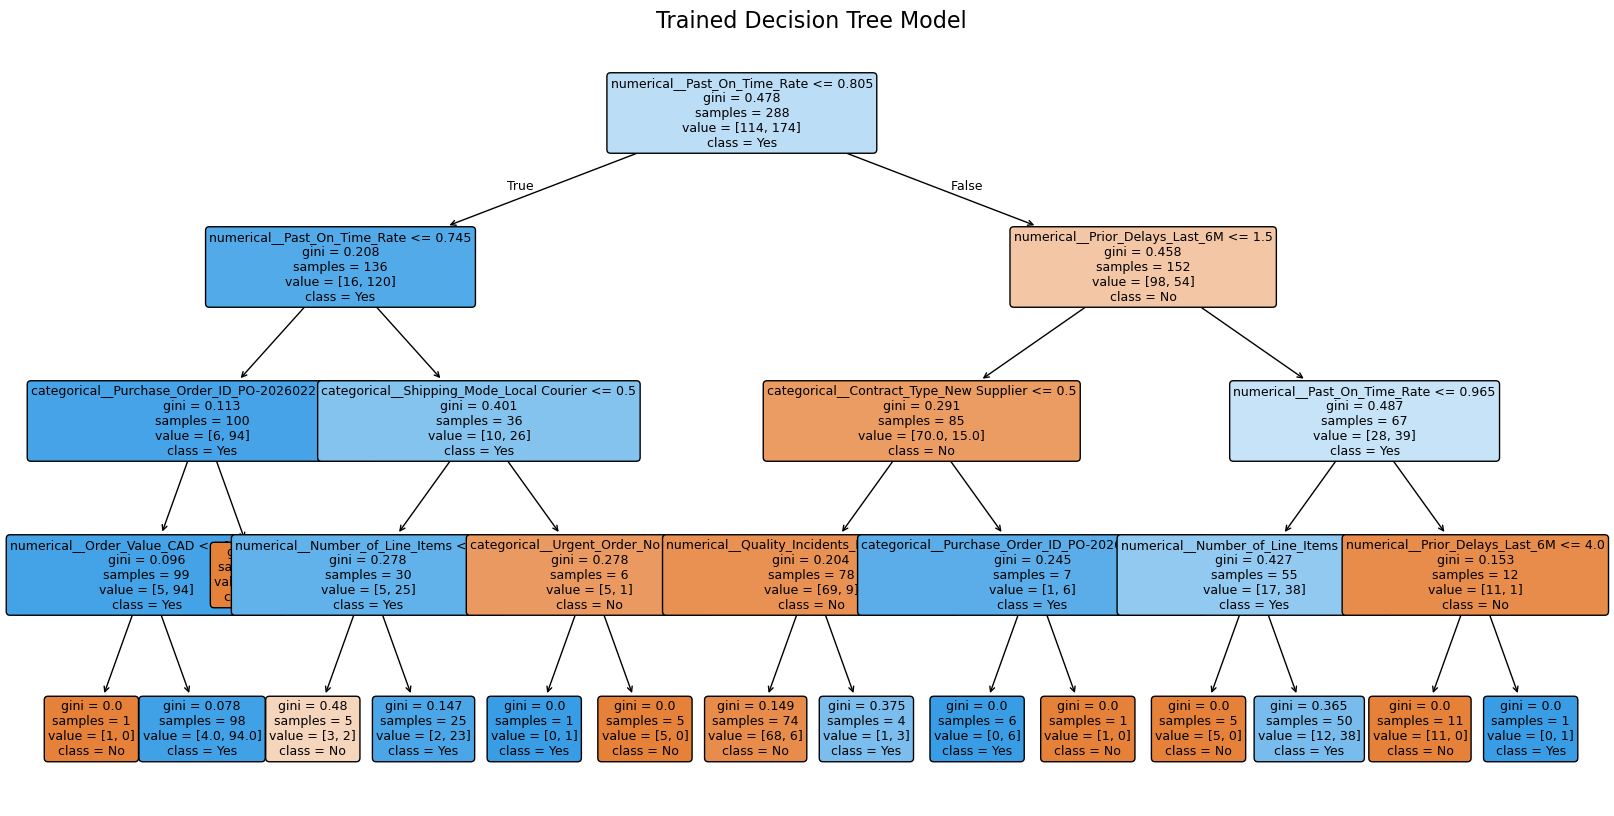

In [73]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=[str(c) for c in decision_tree_model.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Trained Decision Tree Model", fontsize=16)
plt.show()

In [75]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()
# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()
# Print the depth of the tree
print("Decision Tree depth:", tree_depth)
# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 15


In [79]:
y_pred_dt = decision_tree_model.predict(X_test_processed)
# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [81]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
# Store the actual values from the testing set
"Actual": y_test.values,
# Store the predicted values from the Decision Tree model
"Predicted": y_pred_dt
})
# Print a title for the output
print("Actual vs Predicted Values")
# Print a separator line
print("-" * 50)
# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,No,No
1,Yes,Yes
2,No,No
3,No,No
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,No,No
8,Yes,Yes
9,No,Yes


In [83]:
# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score
# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")
# Display the accuracy value
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.7777777777777778


In [87]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(X_train_processed)
# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)
# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.90625
Decision Tree Testing Accuracy: 0.7777777777777778


In [89]:
# Create a small table to compare training and testing accuracy
dt_accuracy_table = pd.DataFrame({
# Store model evaluation type
"Evaluation Set": ["Training Set", "Testing Set"],
# Store accuracy values
"Accuracy": [dt_train_accuracy, dt_test_accuracy]
})
# Display the accuracy comparison table
display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.906250
1,Testing Set,0.777778


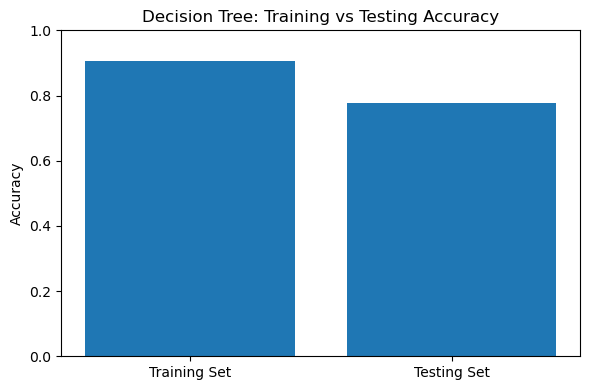

In [91]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Create a figure for the accuracy comparison chart
plt.figure(figsize=(6, 4))
# Create a bar chart for training and testing accuracy
plt.bar(dt_accuracy_table["Evaluation Set"], dt_accuracy_table["Accuracy"])
# Add a title to the chart
plt.title("Decision Tree: Training vs Testing Accuracy")
# Add a label to the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [93]:
# Count actual class values in the testing set
actual_counts = y_test.value_counts()
# Count predicted class values from the Decision Tree model
predicted_counts = pd.Series(y_pred_dt).value_counts()
# Create a comparison table for actual and predicted class counts
class_count_comparison = pd.DataFrame({
# Store actual class counts
"Actual": actual_counts,
# Store predicted class counts
"Predicted": predicted_counts
})
# Fill any missing values with zero
class_count_comparison = class_count_comparison.fillna(0)
# Display the comparison table
display(class_count_comparison)

,Actual,Predicted
Yes,40,44
No,32,28


<Figure size 700x400 with 0 Axes>

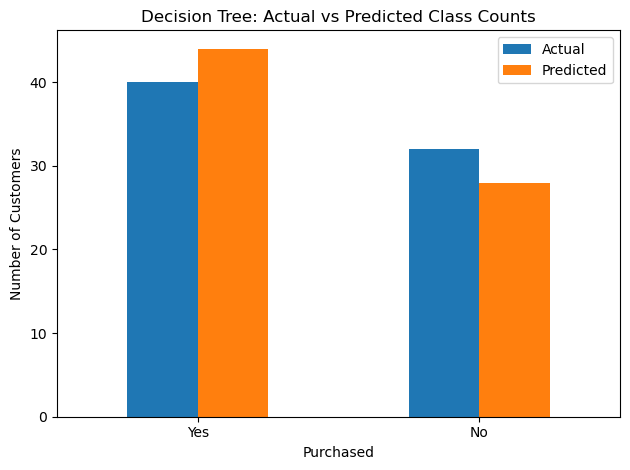

In [95]:
# Create a figure for actual vs predicted class counts
plt.figure(figsize=(7, 4))
# Create a bar chart for actual and predicted class counts
class_count_comparison.plot(kind="bar")
# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")
# Add a label to the x-axis
plt.xlabel("Purchased")
# Add a label to the y-axis
plt.ylabel("Number of Customers")
# Rotate x-axis labels
plt.xticks(rotation=0)
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [97]:
# Import confusion_matrix to calculate the confusion matrix
from sklearn.metrics import confusion_matrix
# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

In [99]:
# Define the class labels in a fixed order
class_labels = ["No", "Yes"]
# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)
# Print a title for the output
print("Decision Tree Confusion Matrix")
# Print a separator line
print("-" * 50)
# Display the confusion matrix values
print(cm_dt)

Decision Tree Confusion Matrix
--------------------------------------------------
[[22 10]
 [ 6 34]]


In [101]:
# Create a DataFrame to show the confusion matrix in a readable table format
cm_dt_table = pd.DataFrame(
# Use the confusion matrix values
cm_dt,
# Set row labels as actual classes
index=["Actual No", "Actual Yes"],
# Set column labels as predicted classes
columns=["Predicted No", "Predicted Yes"]
)
# Display the confusion matrix table
display(cm_dt_table)

,Predicted No,Predicted Yes
Actual No,22,10
Actual Yes,6,34


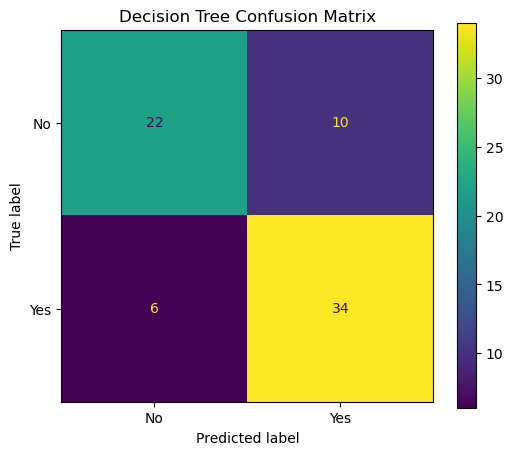

In [103]:
# Create a figure for the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
# Use the Decision Tree confusion matrix
confusion_matrix=cm_dt,
# Use class labels for display
display_labels=class_labels
)
# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")
# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")
# Display the figure
plt.show()

In [105]:
# Extract values from the confusion matrix
tn, fp, fn, tp = cm_dt.ravel()
# Print True Negative value
print("True Negative:", tn)
# Print False Positive value
print("False Positive:", fp)
# Print False Negative value
print("False Negative:", fn)
# Print True Positive value
print("True Positive:", tp)

True Negative: 22
False Positive: 10
False Negative: 6
True Positive: 34


In [107]:
confusion_explanation = pd.DataFrame({
    "Component": [
        "True Negative (Correct Low Risk)",
        "False Positive (Predicted High Risk but actually Low Risk)",
        "False Negative (Predicted Low Risk but actually High Risk)",
        "True Positive (Correct High Risk)"
    ],
    "Meaning": [
        "Model correctly predicted NO delay risk",
        "Model predicted delay risk but supplier was actually fine",
        "Model missed a real delay risk",
        "Model correctly predicted delay risk"
    ],
    "Value": [tn, fp, fn, tp]
})

confusion_explanation

,Component,Meaning,Value
0,True Negative (Correct Low Risk),Model correctly predicted NO delay risk,22
1,False Positive (Predicted High Risk but actual...,Model predicted delay risk but supplier was ac...,10
2,False Negative (Predicted Low Risk but actuall...,Model missed a real delay risk,6
3,True Positive (Correct High Risk),Model correctly predicted delay risk,34


In [109]:
# Import accuracy_score to calculate overall correct predictions
from sklearn.metrics import accuracy_score
# Import precision_score to calculate precision
from sklearn.metrics import precision_score
# Import recall_score to calculate recall
from sklearn.metrics import recall_score
# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score
# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [111]:
# Calculate the accuracy of the Decision Tree model
dt_accuracy = accuracy_score(y_test, y_pred_dt)

In [113]:
# Print the accuracy score
print("Decision Tree Accuracy:")
# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.7777777777777778


In [115]:
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes",zero_division=0)
# Print the precision score
print("Decision Tree Precision:")
# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.7727272727272727


In [117]:
# Calculate recall for the positive class, which is "Yes"
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
# Print the recall score
print("Decision Tree Recall:")
# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.85


In [119]:
#Calculate F1-score for the positive class, which is "Yes"
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
# Print the F1-score
print("Decision Tree F1-Score:")
# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.8095238095238095


In [121]:
# Create a DataFrame to summarize the Decision Tree evaluation metrics
dt_metrics_table = pd.DataFrame({# Store the metric names
"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
# Store the metric values
"Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]
})
# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.777778
1,Precision,0.772727
2,Recall,0.850000
3,F1-Score,0.809524


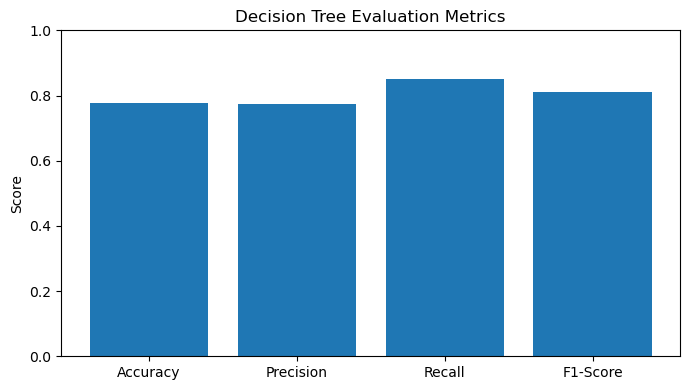

In [123]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Create a figure for the evaluation metrics chart
plt.figure(figsize=(7, 4))
# Create a bar chart for the metrics
plt.bar(dt_metrics_table["Metric"], dt_metrics_table["Score"])
# Add a title to the chart
plt.title("Decision Tree Evaluation Metrics")
# Add a label to the y-axis
plt.ylabel("Score")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Adjust the layout so labels do not overlap
plt.tight_layout()
# Display the chart
plt.show()

In [125]:
# Print a title for the classification report
print("Decision Tree Classification Report")
# Print a separator line
print("-" * 50)
# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.79      0.69      0.73        32
         Yes       0.77      0.85      0.81        40

    accuracy                           0.78        72
   macro avg       0.78      0.77      0.77        72
weighted avg       0.78      0.78      0.78        72



In [129]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
# Allow the tree to grow as much as possible
max_depth=None,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(X_train_processed, y_train)
# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [133]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed)
# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed)
# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)
# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)
# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)
# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.7083333333333334


In [137]:
y_train_pred_controlled = decision_tree_model.predict(X_train_processed)
# Predict the target values for the testing data using the controlled Decision␣Tree
y_test_pred_controlled = decision_tree_model.predict(X_test_processed)
# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)
# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)
# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
# Store the model names
"Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
# Store the training accuracy values
"Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
# Store the testing accuracy values
"Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]
})
# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.90625,0.777778
1,Overfitted Decision Tree,1.00000,0.708333


<Figure size 800x500 with 0 Axes>

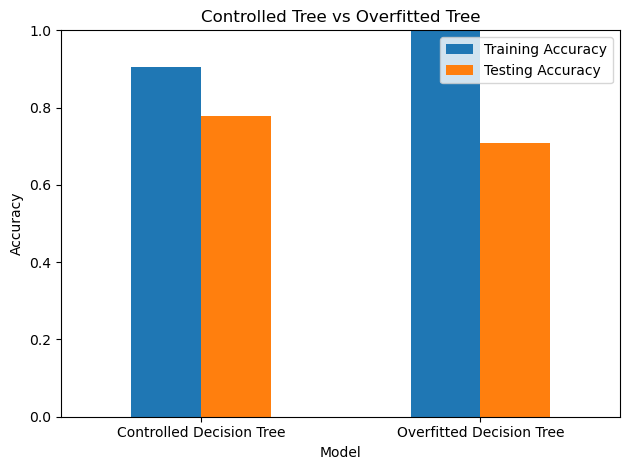

In [139]:
# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")
# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))
# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")
# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")
# Add a label to the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels for better readability
plt.xticks(rotation=0)
# Adjust layout to avoid overlap
plt.tight_layout()
# Display the chart
plt.show()